In [172]:
## Importação das bibliotecas Python, como indicado no texto ##

# biblioteca Python para matemática simbólica 
import sympy as sym
from sympy import * 

# Pacote para computação científica
import numpy as np

# biblioteca para a visualização de dados em Python.
import matplotlib.pyplot as plt

# Este módulo fornece acesso às funções matemáticas (definidas pelo padrão C)
import math

# cmath permite operações com números complexos
import cmath

# O módulo de frações fornece suporte para aritmética de números racionais
from fractions import Fraction

# permite usar latex para exibir equações matemáticas no Jupyter Notebook
from IPython.display import display, Math

In [50]:
def calcular_espectro_amplitude(Cn):
    z = []
    z1 = []
    z.append(0)
    z1.append(0)
    for k in range(2, 20):  # Adicionando 2 ao limite superior para incluir o valor limite
        z.append(k)
        z1.append(Cn.subs(n, k))
    
    plt.stem(z, z1, 'k', markerfmt='ko', label='$|C_n|$')
    plt.legend()
    plt.title('Espectro de amplitude')
    plt.show()

def calcular_espectro_fase(an, bn):
    z = []
    fase = []
    z.append(0)
    fase.append(0)
    for k in range(2, 20):
        z.append(k)
        b = bn.subs(n, k)
        a = an.subs(n, k)
        if a != 0 and b != 0:  # Verificar se tanto an quanto bn não são zero
            fase.append(atan2(-b, a))
        else:
            fase.append(0)  # Defina a fase como zero se an ou bn forem zero

    plt.stem(z, fase, 'k', markerfmt='ko', label='$\\theta_n$')
    plt.legend()
    plt.title('Espectro de fase')
    plt.show()

# Questão 1

## (b)


In [63]:
#from sympy.abc import t
f = sym.Piecewise((1, (-pi <= t) & (t <=pi)), (0, (pi <= t) & (t <=10*pi)), (0, True))
s = fourier_series(f, (t, -pi, 10*pi))
s1 = s.truncate(n = 4)
display(Math('f(t) = ' + latex(s1)))

<IPython.core.display.Math object>

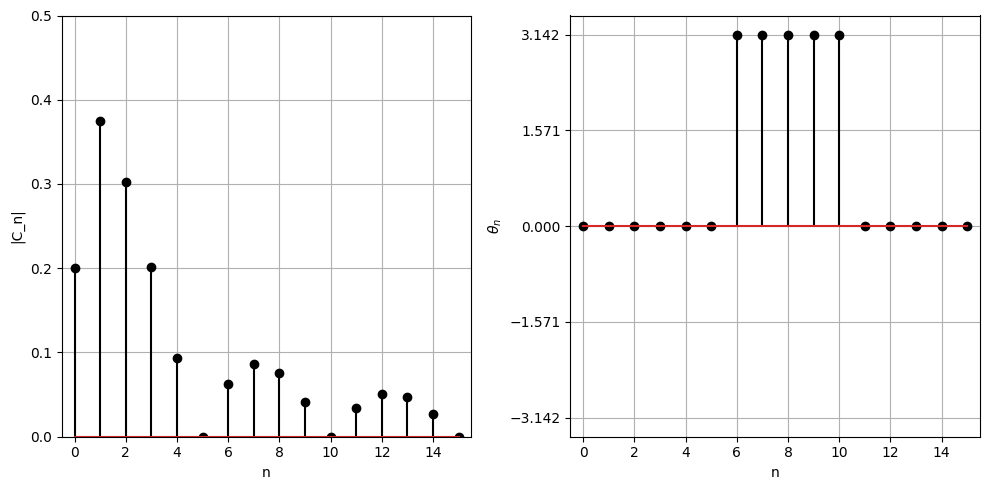

In [211]:
import numpy as np
import matplotlib.pyplot as plt

n = np.arange(1, 16)
an = 2 / (np.pi * n) * np.sin(np.pi * n / 5)
bn = np.zeros_like(n)

Cn = np.concatenate(([1 / 5], np.sqrt(an ** 2 + bn ** 2)))
thetan = np.concatenate(([np.arctan(0)], np.arctan2(-bn, an)))
n = np.concatenate(([0], n))

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.stem(n, Cn, 'k.')
plt.xlabel('n')
plt.ylabel('|C_n|')
plt.axis([-0.5, 15.5, 0, 0.5])
plt.grid(True)

plt.subplot(1, 2, 2)
plt.stem(n, thetan, 'k.')
plt.xlabel('n')
plt.ylabel('$\\theta_n$')
plt.axis([-0.5, 15.5, -1.1 * np.pi, 1.1 * np.pi])
plt.grid(True)
plt.yticks(np.arange(-np.pi, np.pi + np.pi / 2, np.pi / 2))

plt.tight_layout()
plt.show()

## (c)

In [218]:
# Definindo variáveis simbólicas
t, n = symbols('t n', real=True)

# Definindo a função
f = 0.5 + (1 / pi) * Sum(cos(n * t + pi / 2) / n, (n, 1, oo))

# Exibindo a função
display(f)

Sum(-sin(n*t)/n, (n, 1, oo))/pi + 0.5

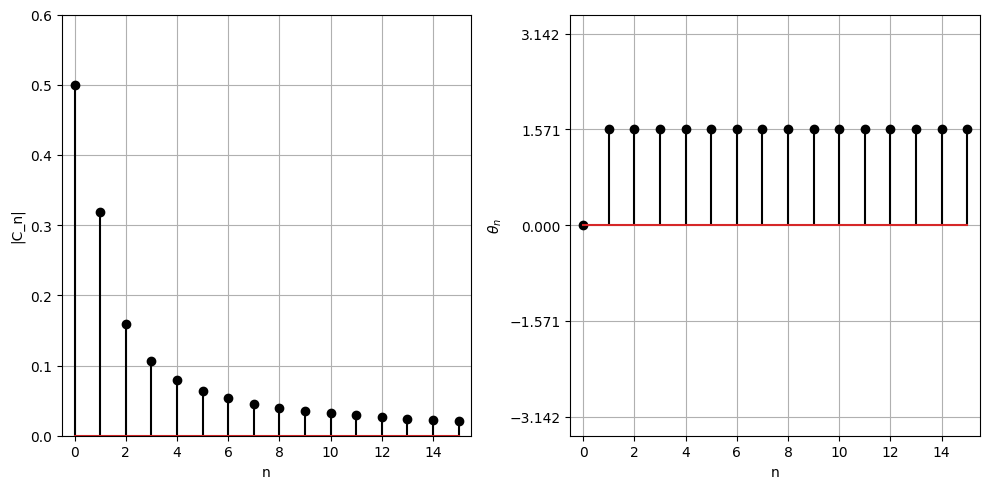

In [217]:

n = np.arange(1, 16)
bn = -1 / (np.pi * n)
an = np.zeros_like(n)

Cn = np.concatenate(([1 / 2], np.sqrt(an ** 2 + bn ** 2)))
thetan = np.concatenate(([np.arctan(0)], np.arctan2(-bn, an)))
n = np.concatenate(([0], n))

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.stem(n, Cn, 'k.')
plt.xlabel('n')
plt.ylabel('|C_n|')
plt.axis([-0.5, 15.5, 0, 0.6])
plt.grid(True)

plt.subplot(1, 2, 2)
plt.stem(n, thetan, 'k.')
plt.xlabel('n')
plt.ylabel('$\\theta_n$')
plt.axis([-0.5, 15.5, -1.1 * np.pi, 1.1 * np.pi])
plt.grid(True)
plt.yticks(np.arange(-np.pi, np.pi + np.pi / 2, np.pi / 2))

plt.tight_layout()
plt.show()

## (d)

In [224]:
# Definindo variáveis simbólicas
t, n = symbols('t n', real=True)

# Definindo a função periódica
f = Sum(((-1)**((n + 1)//2 + 1) * 4 / ((2 * (n - 1) + 1) * pi) * sin((2 * (n - 1) + 1) * t)), (n, 1, oo))

# Imprimindo a série de Fourier
display(f)

Sum(4*(-1)**(floor(n/2 + 1/2) + 1)*sin(t*(2*n - 1))/(pi*(2*n - 1)), (n, 1, oo))

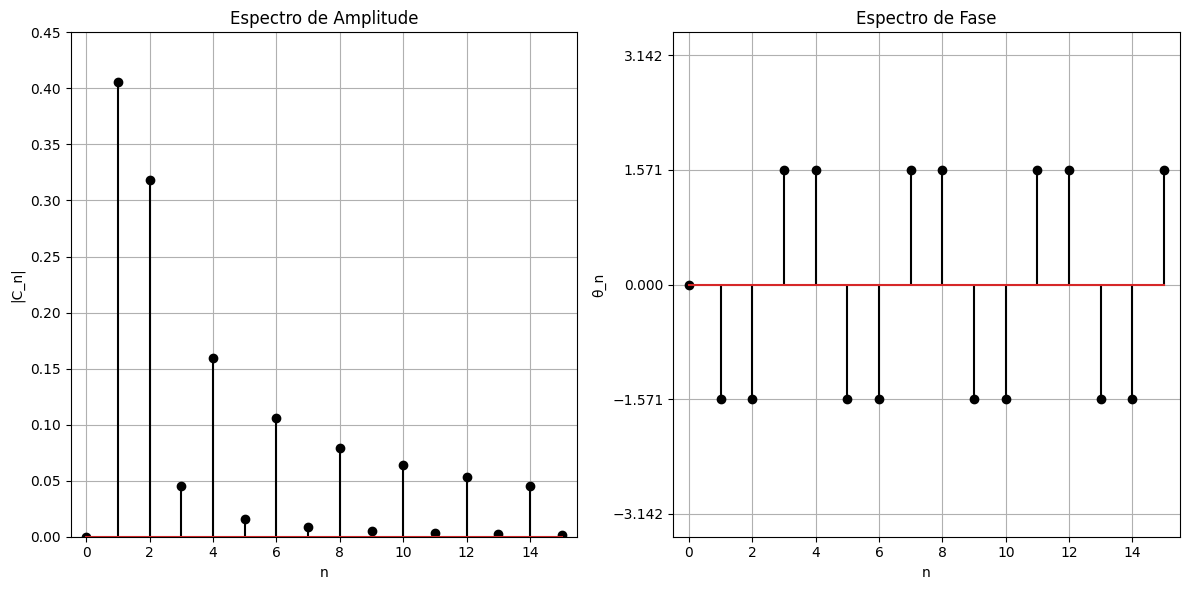

In [225]:
# Valores de n
n = np.arange(1, 16)

# Coeficientes bn
bn = 2 / (np.pi * n) * (2 / (np.pi * n) * np.sin(np.pi * n / 2) - np.cos(np.pi * n / 2))

# Coeficientes an (todos zeros)
an = np.zeros_like(n)

# Módulo de Cn
Cn = np.sqrt(an**2 + bn**2)

# Fase de Cn
thetan = np.arctan2(-bn, an)

# Adicionando n = 0
n = np.insert(n, 0, 0)
Cn = np.insert(Cn, 0, 0)
thetan = np.insert(thetan, 0, 0)

# Plotando
plt.figure(figsize=(12, 6))

# Espectro de amplitude
plt.subplot(1, 2, 1)
plt.stem(n, Cn, 'k.')
plt.xlabel('n')
plt.ylabel('|C_n|')
plt.title('Espectro de Amplitude')
plt.axis([-.5, 15.5, 0, 0.45])
plt.grid(True)

# Espectro de fase
plt.subplot(1, 2, 2)
plt.stem(n, thetan, 'k.')
plt.xlabel('n')
plt.ylabel('θ_n')
plt.title('Espectro de Fase')
plt.axis([-.5, 15.5, -1.1 * np.pi, 1.1 * np.pi])
plt.yticks(np.arange(-np.pi, np.pi + np.pi / 2, np.pi / 2))
plt.grid(True)

plt.tight_layout()
plt.show()

## (e)

In [134]:
#from sympy.abc import t
f = sym.Piecewise((t, (0 <= t) & (t <=1)), (0, (1 <= t) & (t <=3)), (0, True))
s = fourier_series(f, (t, 0, 3))
s1 = s.truncate(n = 4)
display(Math('f(t) = ' + latex(s1)))

<IPython.core.display.Math object>

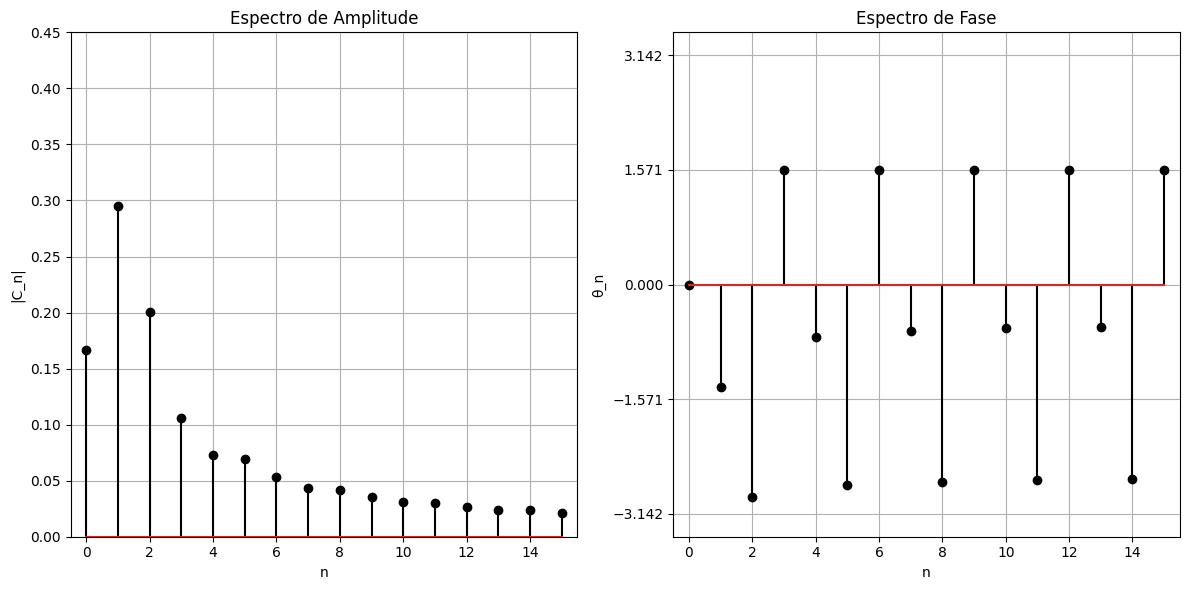

In [226]:
# Valores de n
n = np.arange(1, 16)

# Coeficientes an
an = 3 / (2 * np.pi**2 * n**2) * (np.cos(2 * np.pi * n / 3) + 2 * np.pi * n / 3 * np.sin(2 * np.pi * n / 3) - 1)

# Coeficientes bn
bn = 3 / (2 * np.pi**2 * n**2) * (np.sin(2 * np.pi * n / 3) - 2 * np.pi * n / 3 * np.cos(2 * np.pi * n / 3))

# Módulo de Cn
Cn = np.sqrt(an**2 + bn**2)

# Fase de Cn
thetan = np.arctan2(-bn, an)

# Adicionando n = 0
n = np.insert(n, 0, 0)
Cn = np.insert(Cn, 0, 1 / 6)  # Primeiro termo de Cn
thetan = np.insert(thetan, 0, 0)  # Fase para n = 0

# Plotando
plt.figure(figsize=(12, 6))

# Espectro de amplitude
plt.subplot(1, 2, 1)
plt.stem(n, Cn, 'k.')
plt.xlabel('n')
plt.ylabel('|C_n|')
plt.title('Espectro de Amplitude')
plt.axis([-.5, 15.5, 0, 0.45])
plt.grid(True)

# Espectro de fase
plt.subplot(1, 2, 2)
plt.stem(n, thetan, 'k.')
plt.xlabel('n')
plt.ylabel('θ_n')
plt.title('Espectro de Fase')
plt.axis([-.5, 15.5, -1.1 * np.pi, 1.1 * np.pi])
plt.yticks(np.arange(-np.pi, np.pi + np.pi / 2, np.pi / 2))
plt.grid(True)

plt.tight_layout()
plt.show()

## (f)

In [231]:
# Definindo variáveis simbólicas
t, n = symbols('t n')

# Definindo a série de Fourier
f = 0.5 + Sum(6/pi**2 * cos((2*n+1)*pi*t/3) / ((2*n+1)**2), (n, 0, oo))

# Imprimindo a série de Fourier
display(f)

Sum(6*cos(pi*t*(2*n + 1)/3)/(pi**2*(2*n + 1)**2), (n, 0, oo)) + 0.5

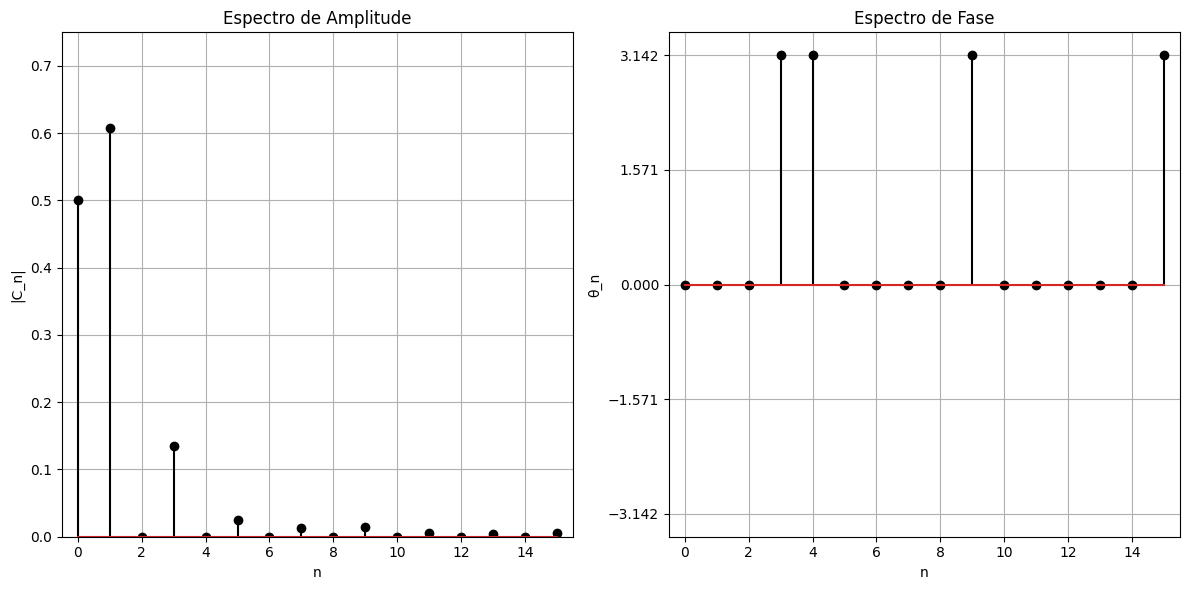

In [227]:
# Valores de n
n = np.arange(1, 16)

# Coeficientes an
an = 6 / (np.pi**2 * n**2) * (np.cos(np.pi * n / 3) - np.cos(2 * np.pi * n / 3))

# Coeficientes bn
bn = np.zeros_like(n)

# Módulo de Cn
Cn = np.sqrt(an**2 + bn**2)

# Fase de Cn
thetan = np.arctan2(-bn, an)

# Adicionando n = 0
n = np.insert(n, 0, 0)
Cn = np.insert(Cn, 0, 1 / 2)  # Primeiro termo de Cn
thetan = np.insert(thetan, 0, 0)  # Fase para n = 0

# Plotando
plt.figure(figsize=(12, 6))

# Espectro de amplitude
plt.subplot(1, 2, 1)
plt.stem(n, Cn, 'k.')
plt.xlabel('n')
plt.ylabel('|C_n|')
plt.title('Espectro de Amplitude')
plt.axis([-.5, 15.5, 0, 0.75])
plt.grid(True)

# Espectro de fase
plt.subplot(1, 2, 2)
plt.stem(n, thetan, 'k.')
plt.xlabel('n')
plt.ylabel('θ_n')
plt.title('Espectro de Fase')
plt.axis([-.5, 15.5, -1.1 * np.pi, 1.1 * np.pi])
plt.yticks(np.arange(-np.pi, np.pi + np.pi / 2, np.pi / 2))
plt.grid(True)

plt.tight_layout()
plt.show()

# Questão 2

## (a)

In [165]:
# Definindo variáveis simbólicas
t, n = symbols('t n', real=True)

# Definindo a função periódica
f = 1/3 + 4/pi**2 * summation((-1)**n/n**2 * cos(n*sp.pi*t), (n, 1, oo))

# Imprimindo a série trigonométrica compacta de Fourier
display(f)

4*Sum((-1)**n*cos(pi*n*t)/n**2, (n, 1, oo))/pi**2 + 0.333333333333333

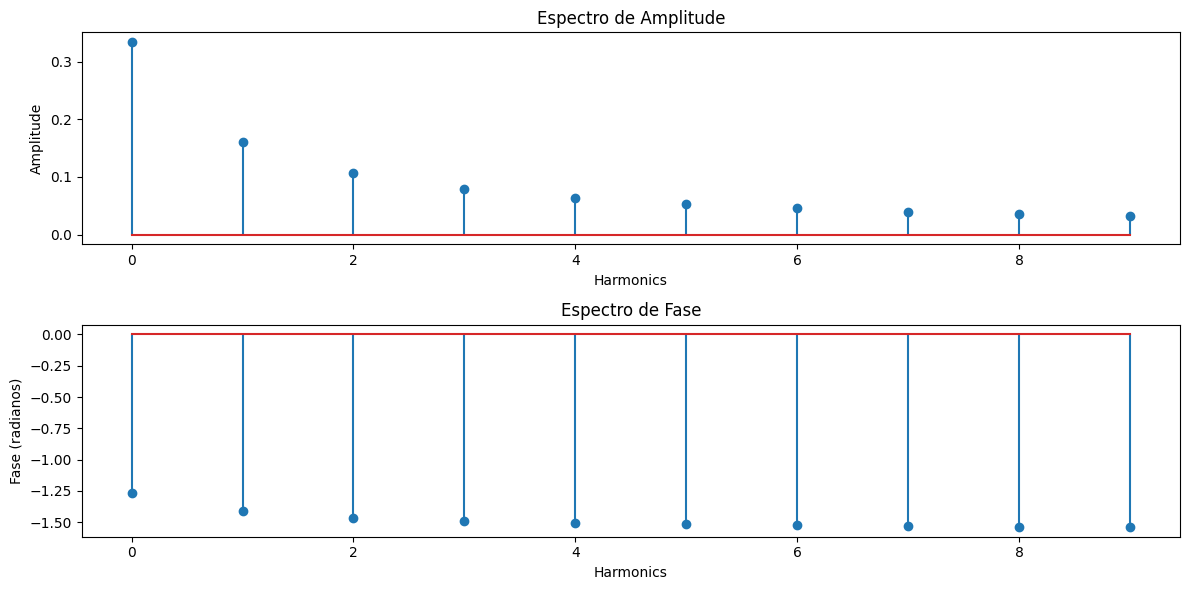

In [144]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Definindo o período e a frequência angular
T = 1  # Período em segundos
omega = 2 * np.pi / T  # Frequência angular

# Definindo a função para o sinal periódico
def f(t):
    return t**2 if 0 <= t < T else f(t % T)

# Funções para calcular os coeficientes da série de Fourier
def a0():
    return (2 / T) * quad(lambda t: f(t), 0, T)[0]

def an(n):
    return (2 / T) * quad(lambda t: f(t) * np.cos(2 * np.pi * n * t / T), 0, T)[0]

def bn(n):
    return (2 / T) * quad(lambda t: f(t) * np.sin(2 * np.pi * n * t / T), 0, T)[0]

# Calculando os coeficientes a0, an e bn para os primeiros N termos da série
N = 10
coef_a0 = a0()
coef_an = np.array([an(n) for n in range(1, N+1)])
coef_bn = np.array([bn(n) for n in range(1, N+1)])

# Calculando os espectros de amplitude e fase
amplitude = np.sqrt(coef_an**2 + coef_bn**2)
fase = np.arctan2(coef_bn, coef_an)

# Plotando os espectros de amplitude e fase
plt.figure(figsize=(12, 6))

# Espectro de amplitude
plt.subplot(2, 1, 1)
plt.stem(range(N), amplitude)
plt.title('Espectro de Amplitude')
plt.xlabel('Harmonics')
plt.ylabel('Amplitude')

# Espectro de fase
plt.subplot(2, 1, 2)
plt.stem(range(N), fase)
plt.title('Espectro de Fase')
plt.xlabel('Harmonics')
plt.ylabel('Fase (radianos)')

plt.tight_layout()
plt.show()

## (b)

In [166]:
# Definindo os símbolos e parâmetros
t, A = symbols('t A')

# Definindo a função x(t)
x_t = 2*A/pi * (cos(pi*t - pi/2) + (1/2)*cos(2*pi*t + pi/2) + (1/3)*cos(3*pi*t - pi/2) + (1/4)*cos(4*pi*t + pi/2))

# Imprimindo a função
display(x_t)

2*A*(sin(pi*t) - 0.5*sin(2*pi*t) + 0.333333333333333*sin(3*pi*t) - 0.25*sin(4*pi*t))/pi

# Questão 3


## (a)

$$
x(t) = \frac{1}{3} + \frac{4}{\pi^2} \sum_{n=1}^{\infty} \frac{(-1)^n}{n^2} \cos(n\pi t), -1 \leq t \leq 1.
$$

A potência de  x(t)  é:

$$
P_x = \frac{1}{2} \int_{-1}^{1} \left( t \right)^4 dt = \frac{1}{5}.
$$

Além disso, o teorema de Parseval afirma:

$$
P_x = C_0^2 + \sum_{n=1}^{\infty} (C_n^2) = \left( \frac{1}{3} \right)^2 + \frac{1}{2} \sum_{n=1}^{\infty} \left( \frac{4(-1)^n}{\pi^2 \cdot 2n^2} \right)^2 = \left( \frac{1}{9} \right) + \frac{8}{\pi^4} \sum_{n=1}^{\infty} \frac{1}{n^4} = \left( \frac{1}{9} \right) + \left( \frac{8}{90} \right) = \frac{1}{5}.
$$

Claramente, o teorema de Parseval é verificado.

## (b)

Se a série de Fourier de N termos for denotada por  w(t) , então
$$
w(t) = \frac{1}{3} + \frac{4}{\pi^2} \sum_{n=1}^{N} \frac{(-1)^n}{n^2} \cos(n\pi t), -1 \leq t \leq 1.
$$
Para tornar a potência do sinal de erro menor que 1% de $ P_x $, a potência $ P_w $ precisa ser pelo menos $ 0.99P_x = 0.198 $. Portanto,
$$
P_w = \frac{1}{9} + \frac{8}{\pi^4} \sum_{n=1}^{N} \frac{1}{n^4} \geq 0.198.
$$
Para $ N = 1 ,  P_w = 0.1111 $, e para $ N = 2 $, $ P_w = 0.19323 $. Para $ N = 3 $, $ P_w = 0.19837 $, que é maior que 0.198. Assim, $ N = 3 $.

## (c)

$$
x(t) = \frac{2A}{\pi} (-1)^{n+1} \sum_{n=1}^{\infty} \frac{1}{n} \sin(n\pi t), -\pi \leq t \leq \pi.
$$

A potência de $ x(t) $ é dada por
$$
P_x = \frac{1}{2} \int_{-1}^{1} (At)^2 dt = \frac{A^2}{3}.
$$

Além disso, o teorema de Parseval afirma
$$
P_x = C_0^2 + \sum_{n=1}^{\infty} \frac{C_n^2}{2} = \frac{1}{2} \sum_{n=1}^{\infty} \frac{4A^2}{\pi^2 \cdot 2n^2} = \frac{2A^2}{\pi^2} \sum_{n=1}^{\infty} \frac{1}{n^2} = \frac{A^2}{3}.
$$

Claramente o teorema de Parseval é válido.

## (d)

Se a série de Fourier de N termos for denotada por $ w(t) $, então
$$
w(t) = \frac{2A}{\pi} (-1)^{n+1} \sum_{n=1}^{\infty} \frac{1}{n} \sin(n\pi t), -\pi \leq t \leq \pi.
$$

O uso e/ou distribuição das soluções por estudantes são proibidos.

A potência $ P_w $ deve ser no mínimo $  0.90 \frac{A^2}{3} = 0.3A^2  $. Portanto,
$$
P_w = \frac{1}{2} \sum_{n=1}^{N} \frac{4A^2}{\pi^2 \cdot 2n^2} \geq 0.3A^2.
$$

Para $ N = 1 $, $ P_w = 0.2026A^2 $, e para $ N = 2 $, $ P_w = 0.2533A^2 $. Continuando até $ N = 5 $, $ P_w = 0.29658A^2 $. Para $ N = 6 $, $ P_w = 0.30222A^2 $, o que é maior do que $ 0.3A^2 $. Assim, $ N = 6 $.


# Questão 4

# Questão 5


In [204]:

# Definindo variáveis simbólicas
t, n, j = symbols('t n j', real=True)

# Definindo a função periódica
f = (2/pi) * summation((1/(1-4*n**2))*exp(j*2*n*t), (n, -oo, oo))

# Imprimindo a série trigonométrica compacta de Fourier
display(f)

2*Sum(exp(2*j*n*t)/(1 - 4*n**2), (n, -oo, oo))/pi

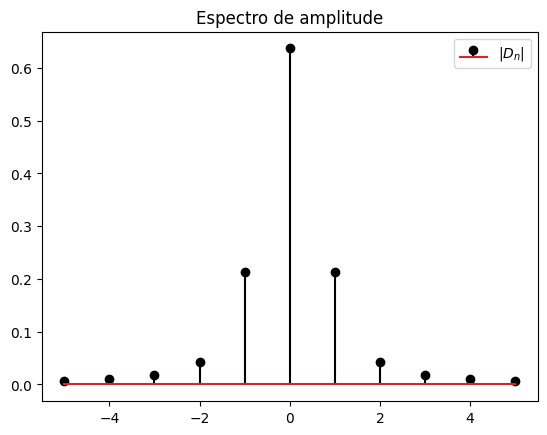

In [210]:
# Definindo a expressão para Dn
n = symbols('n')
Dn = 2 / (pi * (1 - 4 * n ** 2))

# Valores de z
z = [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5]

# Calculando os valores de Dn (módulo) para cada valor em z
z1 = [abs(Dn.subs(n, valor)) for valor in z]

# Plotando o gráfico
plt.stem(z, z1, 'k', markerfmt='ko', label='$|D_n|$')
plt.legend()
plt.title('Espectro de amplitude')
plt.show()

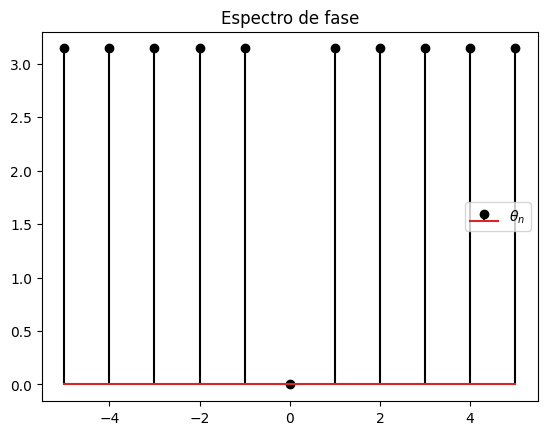

In [188]:

z = [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5]
z1 = [np.pi, np.pi, np.pi, np.pi, np.pi, 0, np.pi, np.pi, np.pi, np.pi, np.pi]

plt.stem(z, z1, 'k', markerfmt='ko', label='$\\theta_n$')
plt.legend()
plt.title('Espectro de fase')
plt.show()